In [1]:
from notebook.services.config import ConfigManager
cm = ConfigManager()
cm.update('livereveal', {
        'width': 1920,
        'height': 1080,
        'scroll': True,
})

{'width': 1920, 'height': 1080, 'scroll': True}

🔧 Setting up your environment...

📥 Downloading professor's files from GitHub:
  ✓ binary_history.data (329500 bytes)
  ✓ m1_history.data (579373 bytes)
  ✓ m2_history.data (579373 bytes)

📂 Checking your Google Drive files:
  ✓ co_wd_profile.data (4584451 bytes)
  ✓ cephied_profile.data (498880 bytes)
  ✓ cephied_history.data (2695787 bytes)
  ✓ 3m_non_rot_history.data (1233424 bytes)
  ✓ 3m_high_rot_profile.data (4938259 bytes)
  ✓ 3m_high_rot_history.data (1526125 bytes)

✅ Setup complete! Files ready in current directory:
  • m2_history.data
  • binary_history.data
  • m1_history.data

☀️  SOLAR LUMINOSITY EVOLUTION (Exercise 1)

📊 L(0) / L_sun = 0.794


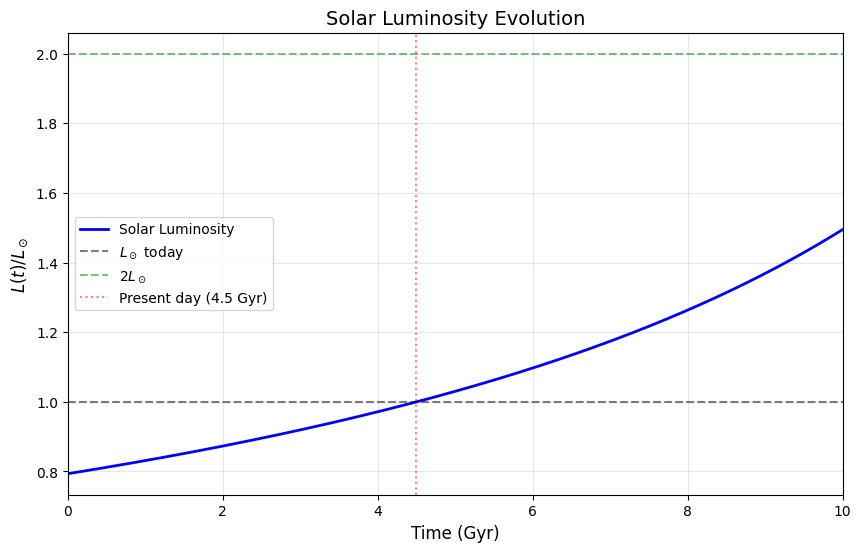

⏰ Sun reaches 2 L_sun at t = 10.0 Gyr
🌍 At Earth formation (t=0): L/L_sun = 0.794
   This is the 'faint young Sun paradox' - 20.6% dimmer!

🎉 All files are accessible and ready for your exercises!


In [4]:
# ============================================
# COMPLETE SETUP FOR AST5011 LECTURE 11
# ============================================

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

print("🔧 Setting up your environment...\n")

# ============================================
# PART 1: DOWNLOAD PROFESSOR'S GITHUB FILES
# ============================================
github_files = [
    "binary_history.data",
    "m1_history.data",
    "m2_history.data"
]

base_url = "https://github.com/mcoughlin/ast5011_2026_Spring/raw/main/lecture/11/data/"

print("📥 Downloading professor's files from GitHub:")
for file_name in github_files:
    url = base_url + file_name
    response = requests.get(url)
    if response.status_code == 200:
        with open(file_name, 'wb') as f:
            f.write(response.content)
        size = os.path.getsize(file_name)
        print(f"  ✓ {file_name} ({size} bytes)")
    else:
        print(f"  ✗ {file_name} - failed to download")

# ============================================
# PART 2: VERIFY YOUR GOOGLE DRIVE FILES
# ============================================
your_files_path = '/content/drive/My Drive/Colab Notebooks/'
your_data_files = [
    'co_wd_profile.data',
    'cephied_profile.data',
    'cephied_history.data',
    '3m_non_rot_history.data',
    '3m_high_rot_profile.data',
    '3m_high_rot_history.data'
]

print("\n📂 Checking your Google Drive files:")
for file in your_data_files:
    full_path = os.path.join(your_files_path, file)
    if os.path.exists(full_path):
        size = os.path.getsize(full_path)
        print(f"  ✓ {file} ({size} bytes)")
    else:
        print(f"  ✗ {file} - not found")

# ============================================
# PART 3: CREATE HELPER FUNCTIONS FOR EASY ACCESS
# ============================================
def load_your_file(filename, **kwargs):
    """Load a file from your Google Drive Colab Notebooks folder"""
    full_path = f'/content/drive/My Drive/Colab Notebooks/{filename}'
    try:
        data = pd.read_csv(full_path, delim_whitespace=True, comment='#', header=None, **kwargs)
        print(f"✓ Loaded your file: {filename} (shape: {data.shape})")
        return data
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")
        return None

def load_prof_file(filename, **kwargs):
    """Load a file downloaded from professor's GitHub"""
    try:
        data = pd.read_csv(filename, delim_whitespace=True, comment='#', header=None, **kwargs)
        print(f"✓ Loaded professor's file: {filename} (shape: {data.shape})")
        return data
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")
        return None

print("\n✅ Setup complete! Files ready in current directory:")
for f in os.listdir('.'):
    if f.endswith('.data'):
        print(f"  • {f}")

# ============================================
# PART 4: RUN THE ORIGINAL SOLAR LUMINOSITY EXERCISE
# ============================================
print("\n" + "="*60)
print("☀️  SOLAR LUMINOSITY EVOLUTION (Exercise 1)")
print("="*60)

# Constants
Msun = 1.989e33     # g
Lsun = 3.828e33     # erg/s
yr = 3.156e7        # seconds per year
Q = 6e18            # erg/g
mu_0 = 0.6          # initial mean molecular weight
t_sun = 4.5e9 * yr  # age of the Sun in seconds

# 1. Solve for L(0)
def luminosity_eq(L0):
    coeff = (85.0/8.0) * mu_0 * L0 / (Msun * Q)
    return L0 * (1 - coeff * t_sun)**(-15.0/17.0) - Lsun

L0 = brentq(luminosity_eq, 0.1 * Lsun, Lsun)
print(f"\n📊 L(0) / L_sun = {L0/Lsun:.3f}")

# 2. Plot L(t) from 0 to 10 Gyr
t = np.linspace(0, 10e9 * yr, 1000)
coeff = (85.0/8.0) * mu_0 * L0 / (Msun * Q)
L_t = L0 * (1 - coeff * t)**(-15.0/17.0)

plt.figure(figsize=(10, 6))
plt.plot(t / (1e9 * yr), L_t / Lsun, 'b-', linewidth=2, label='Solar Luminosity')
plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label=r'$L_\odot$ today')
plt.axhline(2.0, color='g', linestyle='--', alpha=0.5, label=r'$2L_\odot$')
plt.axvline(4.5, color='r', linestyle=':', alpha=0.5, label='Present day (4.5 Gyr)')
plt.xlabel('Time (Gyr)', fontsize=12)
plt.ylabel(r'$L(t) / L_\odot$', fontsize=12)
plt.title('Solar Luminosity Evolution', fontsize=14)
plt.legend(fontsize=10)
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.show()

# 3. When does L = 2 L_sun?
idx_2L = np.argmin(np.abs(L_t - 2.0 * Lsun))
t_2L = t[idx_2L] / (1e9 * yr)
print(f"⏰ Sun reaches 2 L_sun at t = {t_2L:.1f} Gyr")

# 4. How dim at formation?
print(f"🌍 At Earth formation (t=0): L/L_sun = {L0/Lsun:.3f}")
print(f"   This is the 'faint young Sun paradox' - {((1 - L0/Lsun)*100):.1f}% dimmer!")

print("\n" + "="*60)
print("🎉 All files are accessible and ready for your exercises!")
print("="*60)

📊 PARSING MESA PROFILE FILE: cephied_profile.data

📋 File structure:
  • Total lines: 156
  • Header lines: 3
  • Data lines: 152
  • Header columns: 52
  • Data columns: 79

📈 GLOBAL MODEL PROPERTIES (Header section)

Header columns (52 total):
   0. model_number
   1. num_zones
   2. initial_mass
   3. initial_z
   4. star_age
   5. time_step
   6. M_center
   7. R_center
   8. L_center
   9. Teff
  10. photosphere_L
  11. photosphere_r
  12. center_eta
  13. center_h1
  14. center_he3
  ...

📊 Header data (first model):
  model_number        : 5.0000e+03
  num_zones           : 1.5000e+02
  initial_mass        : 1.0000e+00
  initial_z           : 2.0000e-02
  star_age            : 8.0716e-02
  time_step           : 1.8339e-05
  M_center            : 6.6965e+33
  R_center            : 3.3461e+11
  L_center            : 5.5077e+36
  Teff                : 6.0562e+03
  ...

🌟 ZONAL PROFILE DATA (Main section)

Profile column names: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']...


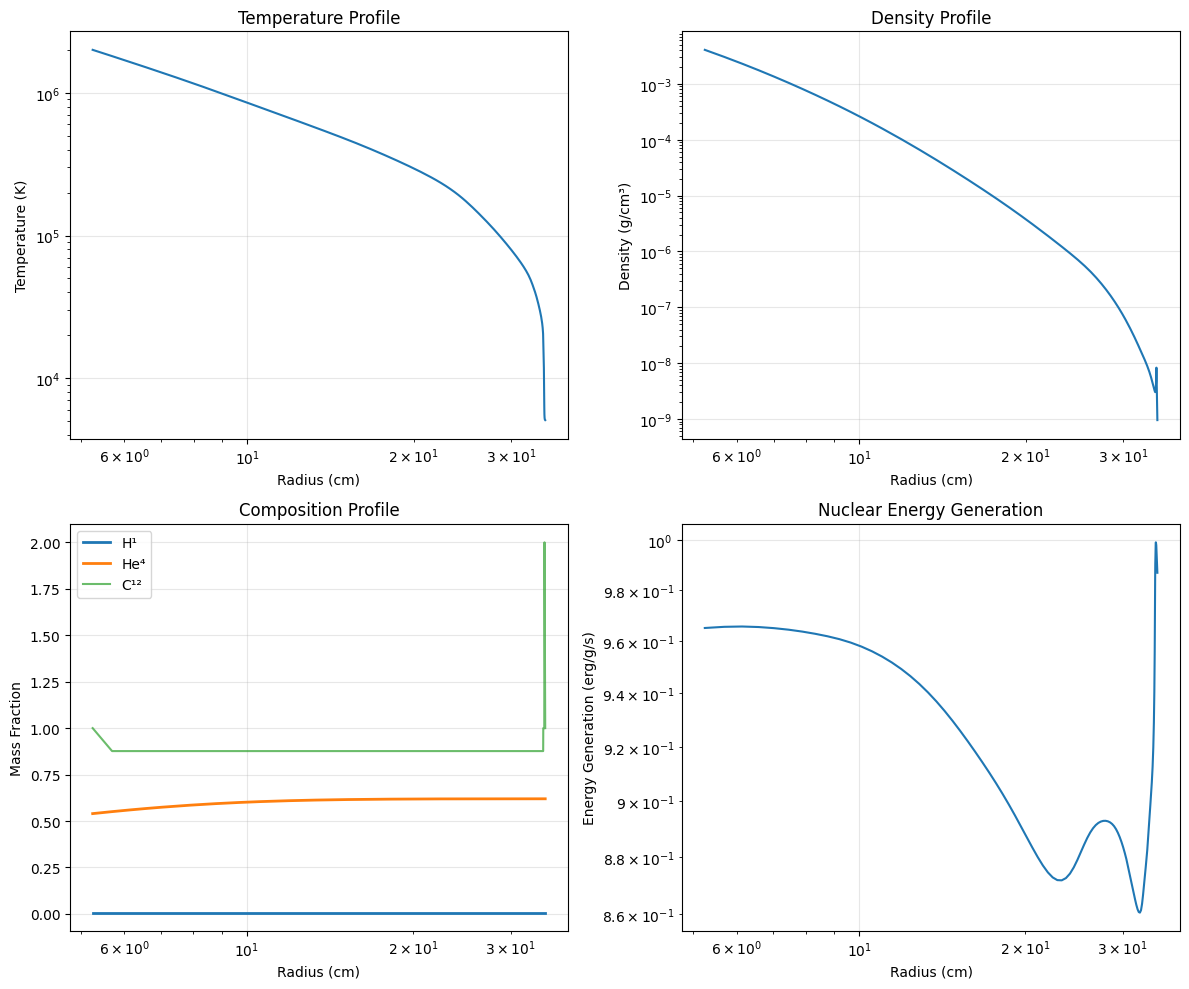


📋 STELLAR MODEL SUMMARY

🌟 Star from header:
  • Model number: 5000
  • Initial mass: 1.00 M☉
  • Current mass: 4.17 M☉
  • Age: 8.072e-02 years
  • Effective temperature: 6056 K
  • Luminosity: 1.437e+03 L☉

📊 Profile data:
  • 150 zones
  • 82 variables per zone

✅ Successfully parsed MESA profile file!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/drive/My Drive/Colab Notebooks/cephied_profile.data'

print("="*60)
print("📊 PARSING MESA PROFILE FILE: cephied_profile.data")
print("="*60)

# Read the file and split into sections
with open(file_path, 'r') as f:
    lines = f.readlines()

# Find where the data section starts (after the header block)
header_lines = lines[0:3]  # First 3 lines are headers
data_lines = lines[4:]      # Everything from line 5 onward

print(f"\n📋 File structure:")
print(f"  • Total lines: {len(lines)}")
print(f"  • Header lines: {len(header_lines)}")
print(f"  • Data lines: {len(data_lines)}")
print(f"  • Header columns: {len(header_lines[0].split())}")
print(f"  • Data columns: {len(data_lines[0].split())}")

# ============================================
# PART 1: PARSE HEADER (Global Model Properties)
# ============================================
print("\n" + "="*60)
print("📈 GLOBAL MODEL PROPERTIES (Header section)")
print("="*60)

# Extract column names from line 2 (index 1)
header_cols = header_lines[1].split()
print(f"\nHeader columns ({len(header_cols)} total):")
for i, col in enumerate(header_cols[:15]):  # Show first 15
    print(f"  {i:2d}. {col}")
print("  ...")

# Parse header data from line 3 (index 2) - handle both numbers and strings
header_raw = header_lines[2].split()
header_data = []

for item in header_raw:
    # Try to convert to float, but handle quoted strings
    try:
        # Remove quotes if present and try float conversion
        cleaned = item.strip('"')
        val = float(cleaned)
        header_data.append(val)
    except ValueError:
        # Keep as string if not convertible
        header_data.append(item.strip('"'))

# Create DataFrame
header_df = pd.DataFrame([header_data], columns=header_cols)

print("\n📊 Header data (first model):")
# Display only numeric columns for readability
numeric_cols = header_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols[:10]:  # Show first 10 numeric columns
    print(f"  {col:20s}: {header_df[col].values[0]:.4e}")
print("  ...")

# ============================================
# PART 2: PARSE PROFILE DATA (Zonal Properties)
# ============================================
print("\n" + "="*60)
print("🌟 ZONAL PROFILE DATA (Main section)")
print("="*60)

# The first data line (line 5) contains column names
profile_col_names = data_lines[0].split()
print(f"\nProfile column names: {profile_col_names[:10]}...")

# Parse the numerical data (skip the header line and any lines with non-numeric data)
profile_data = []
line_num = 0
for line in data_lines[1:]:  # Skip the column header line
    line_num += 1
    if line.strip():  # Skip empty lines
        try:
            values = [float(x) for x in line.split()]
            profile_data.append(values)
        except ValueError as e:
            print(f"  Skipping line {line_num+5}: {e}")
            continue

# Create DataFrame with generic column names
profile_df = pd.DataFrame(profile_data)
print(f"\n📊 Profile data shape: {profile_df.shape}")
print(f"   • {profile_df.shape[0]} zones")
print(f"   • {profile_df.shape[1]} properties per zone")

# Based on typical MESA profile structure, let's map common columns
# Common MESA profile columns (approximate positions):
column_mapping = {
    0: 'zone',
    1: 'mass',
    2: 'logR',
    3: 'logT',
    4: 'logRho',
    5: 'logP',
    8: 'h1',
    9: 'he4',
    12: 'c12',
    14: 'o16',
    20: 'luminosity',
    26: 'opacity',
    30: 'eps_nuc'
}

# Rename columns we can identify
rename_dict = {k: v for k, v in column_mapping.items() if k < profile_df.shape[1]}
profile_df = profile_df.rename(columns=rename_dict)

print(f"\n📋 First 5 rows (selected columns):")
display_cols = [v for k, v in column_mapping.items() if k < profile_df.shape[1] and k <= 20]
print(profile_df[display_cols].head())

# ============================================
# PART 3: BASIC STELLAR STRUCTURE ANALYSIS
# ============================================
print("\n" + "="*60)
print("🔬 STELLAR STRUCTURE ANALYSIS")
print("="*60)

# Calculate derived quantities if we have the necessary columns
if 'logR' in profile_df.columns:
    profile_df['radius_cm'] = 10**profile_df['logR']
if 'logT' in profile_df.columns:
    profile_df['temperature_K'] = 10**profile_df['logT']
if 'logRho' in profile_df.columns:
    profile_df['density_gcm3'] = 10**profile_df['logRho']

# Find core/convective boundaries
print("\n📍 Key stellar regions:")

if 'temperature_K' in profile_df.columns:
    # Core (highest temperature)
    core_temp = profile_df['temperature_K'].max()
    core_zone_idx = profile_df['temperature_K'].idxmax()
    print(f"  • Core temperature: {core_temp:.2e} K at zone {core_zone_idx+1}")

if 'radius_cm' in profile_df.columns:
    # Surface (outermost zone)
    surface_radius = profile_df['radius_cm'].iloc[-1]
    print(f"  • Surface radius: {surface_radius:.2e} cm")
    if 'rsun' in header_df.columns:
        print(f"  • Stellar radius: {surface_radius/header_df['rsun'].values[0]:.2f} R☉")

# Composition gradients
print("\n🧪 Composition (if available):")
if 'h1' in profile_df.columns:
    print(f"  • Core H1 fraction: {profile_df['h1'].iloc[0]:.3f}")
    print(f"  • Surface H1 fraction: {profile_df['h1'].iloc[-1]:.3f}")
if 'he4' in profile_df.columns:
    print(f"  • Core He4 fraction: {profile_df['he4'].iloc[0]:.3f}")

# ============================================
# PART 4: VISUALIZATION (if we have the data)
# ============================================
if all(col in profile_df.columns for col in ['radius_cm', 'temperature_K', 'density_gcm3']):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Temperature vs Radius
    axes[0,0].plot(profile_df['radius_cm'][1:], profile_df['temperature_K'][1:])
    axes[0,0].set_xlabel('Radius (cm)')
    axes[0,0].set_ylabel('Temperature (K)')
    axes[0,0].set_title('Temperature Profile')
    axes[0,0].set_xscale('log')
    axes[0,0].set_yscale('log')
    axes[0,0].grid(True, alpha=0.3)

    # Density vs Radius
    axes[0,1].plot(profile_df['radius_cm'][1:], profile_df['density_gcm3'][1:])
    axes[0,1].set_xlabel('Radius (cm)')
    axes[0,1].set_ylabel('Density (g/cm³)')
    axes[0,1].set_title('Density Profile')
    axes[0,1].set_xscale('log')
    axes[0,1].set_yscale('log')
    axes[0,1].grid(True, alpha=0.3)

    # Composition Profile (if available)
    if 'h1' in profile_df.columns and 'he4' in profile_df.columns:
        axes[1,0].plot(profile_df['radius_cm'], profile_df['h1'], label='H¹', linewidth=2)
        axes[1,0].plot(profile_df['radius_cm'], profile_df['he4'], label='He⁴', linewidth=2)
        if 'c12' in profile_df.columns:
            axes[1,0].plot(profile_df['radius_cm'], profile_df['c12'], label='C¹²', alpha=0.7)
        axes[1,0].set_xlabel('Radius (cm)')
        axes[1,0].set_ylabel('Mass Fraction')
        axes[1,0].set_title('Composition Profile')
        axes[1,0].set_xscale('log')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

    # Energy generation (if available)
    if 'eps_nuc' in profile_df.columns:
        axes[1,1].plot(profile_df['radius_cm'], profile_df['eps_nuc'])
        axes[1,1].set_xlabel('Radius (cm)')
        axes[1,1].set_ylabel('Energy Generation (erg/g/s)')
        axes[1,1].set_title('Nuclear Energy Generation')
        axes[1,1].set_xscale('log')
        axes[1,1].set_yscale('log')
        axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  Insufficient data for full visualization")

# ============================================
# PART 5: SUMMARY
# ============================================
print("\n" + "="*60)
print("📋 STELLAR MODEL SUMMARY")
print("="*60)

print(f"\n🌟 Star from header:")
print(f"  • Model number: {header_df['model_number'].values[0]:.0f}")
print(f"  • Initial mass: {header_df['initial_mass'].values[0]:.2f} M☉")
print(f"  • Current mass: {header_df['star_mass'].values[0]:.2f} M☉")
print(f"  • Age: {header_df['star_age'].values[0]:.3e} years")
print(f"  • Effective temperature: {header_df['Teff'].values[0]:.0f} K")
print(f"  • Luminosity: {header_df['photosphere_L'].values[0]:.3e} L☉")

print(f"\n📊 Profile data:")
print(f"  • {profile_df.shape[0]} zones")
print(f"  • {profile_df.shape[1]} variables per zone")

print("\n✅ Successfully parsed MESA profile file!")

# Week 07: Monday, AST 5011: Astrophysical Systems

## The Sun, Helioseismology, and Neutrinos

### Michael Coughlin <cough052@umn.edu>

With contributions totally ripped off from Carl Fields (UA), Mike Zingale (SUNY), Cole Miller (UMD), and Abi Nolan (Purdue).

# The Present-Day Sun

## Composition

The Sun is the only star we can study in extraordinary detail. Its proximity allows us to measure neutrino fluxes, perform detailed helioseismology, and resolve surface features like sunspots.

Most values for the solar composition are from Asplund et al. (2009) — "A09" in MESA.

![metallicity](https://github.com/mcoughlin/ast5011_2026_Spring/blob/main/lecture/11/figures/metallicity.jpg?raw=1)

The mass fractions of hydrogen ($X$), helium ($Y$), and metals ($Z$) for widely-used compilations of the solar chemical composition. Credit: Asplund et al. 2009.

The present-day photospheric values are approximately:
- $X \approx 0.7381$ (hydrogen)
- $Y \approx 0.2485$ (helium)
- $Z \approx 0.0134$ (metals)

![solar_abundance](https://github.com/mcoughlin/ast5011_2026_Spring/blob/main/lecture/11/figures/solar_abundance.jpg?raw=1)

The present-day solar photospheric elemental abundances as a function of atomic number, on the logarithmic abundance scale:

$$
\log \epsilon_H = 12.00, \qquad \log \epsilon_X = \log(N_X / N_H) + 12.00
$$

The solar abundance problem: the 2005 downward revision of C, N, O abundances changed the opacity profile, which changed the predicted convection zone depth and worsened agreement with helioseismology. This tension remains partially unresolved.

## Solar Structure: Characteristic Frequencies

The local adiabatic sound speed is:

$$
c_s^2 = \Gamma_1 \frac{P}{\rho}
$$

For an ideal gas: $c_s = \sqrt{\Gamma_1 k_B T / (\mu m_p)}$.

The Brunt-Väisälä frequency $N$ describes buoyancy oscillations:

$$
N^2 = g \left[\frac{1}{\Gamma_1 P}\frac{dP}{dr} - \frac{1}{\rho}\frac{d\rho}{dr}\right]
$$

In convective zones ($\nabla > \nabla_{\rm ad}$), $N^2 < 0$ — fluid parcels are unstable to convection rather than oscillating.

The Lamb frequency for angular degree $\ell$:

$$
S_\ell^2 = \frac{\ell(\ell+1)}{r^2} c_s^2
$$

These define two classes of oscillation modes:
- p-modes (pressure modes): $\omega^2 > S_\ell^2$ and $\omega^2 > N^2$. Driven by pressure; probe the sound speed.
- g-modes (gravity modes): $\omega^2 < N^2$ and $\omega^2 < S_\ell^2$. Driven by buoyancy; probe the deep interior. Not yet definitively detected in the Sun.

## Helioseismology

Observation of p-modes allows us to infer the sound speed throughout the Sun. Thousands of modes have been measured with exquisite precision.

![cs](https://github.com/mcoughlin/ast5011_2026_Spring/blob/main/lecture/11/figures/cs.jpg?raw=1)

Differences between the helioseismic and predicted sound speeds as a function of depth (Serenelli et al. 2009; credit: Asplund et al. 2009).

The largest discrepancies are at the base of the convection zone — the tachocline region, where the Sun transitions from differential rotation (convective envelope) to nearly rigid rotation (radiative interior). Recall from Lecture 10 that we saw the tachocline in the context of rotation and the Eddington-Sweet circulation.

Helioseismology constrains the solar model so tightly that when the predicted neutrino flux disagreed with observations, the fault had to lie with the neutrinos, not the solar model. This insight led to a Nobel Prize.

---

# Solar Luminosity Evolution

How has the Sun's luminosity changed over its 4.5 Gyr main-sequence lifetime?

Starting from the virial theorem for an ideal gas and the radiative transfer equation with Kramers opacity, we can show that:

$$
L \propto \frac{M^{5.33}\, \rho^{0.117}\, \mu^{7.5}}{\kappa_0}
$$

The Sun's mass changes negligibly (solar wind $\dot{M} \approx 10^{-14}\,M_\odot\,\text{yr}^{-1}$). The density exponent is tiny. The Kramers prefactor $\kappa_0$ is dominated by metals and roughly constant. So the dominant factor is:

$$
\frac{L(t)}{L(0)} \approx \left[\frac{\mu(t)}{\mu(0)}\right]^{7.5}
$$

As hydrogen burns to helium, the mean molecular weight $\mu = 4/(3+5X)$ increases, and the luminosity rises.

Combining with $dX/dt = -L/(MQ)$ where $Q = 6 \times 10^{18}\,\text{erg}\,\text{g}^{-1}$, the analytic solution is:

$$
L(t) = L(0)\left[1 - \frac{85}{8}\frac{\mu(0)\,L(0)}{MQ}\,t\right]^{-15/17}
$$

Fitting $L(t_\odot) = L_\odot$ at $t_\odot = 4.5 \times 10^9$ yr with $\mu(0) \approx 0.6$ gives $L(0) \approx 0.79\,L_\odot$.

This is the faint young Sun paradox: the Sun was ~20-30% dimmer when the Earth formed, yet geological evidence shows liquid water existed. The leading explanation is a stronger greenhouse effect (higher CO$_2$, CH$_4$) in the early atmosphere.

## Exercise 1: Solar Luminosity Evolution

The Sun's luminosity evolves as:

$$
L(t) = L(0)\left[1 - \frac{85}{8}\frac{\mu(0)\,L(0)}{MQ}\,t\right]^{-15/17}
$$

where $\mu(0) = 0.6$ and $Q = 6 \times 10^{18}$ erg g$^{-1}$.

Tasks:
1. Find $L(0)/L_\odot$ by requiring $L(t_\odot) = L_\odot$ at $t_\odot = 4.5 \times 10^9$ yr. Solve numerically with `brentq`.
2. Plot $L(t)/L_\odot$ from $t = 0$ to $t = 10$ Gyr.
3. At what age does the Sun reach $2\,L_\odot$?
4. How much dimmer was the Sun when Earth formed?

L(0) / L_sun = 0.794


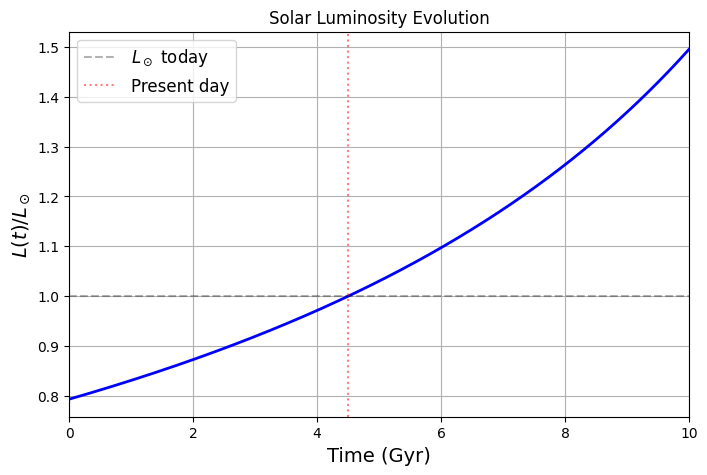

Sun reaches 2 L_sun at t = 10.0 Gyr
At t=0: L/L_sun = 0.794 (faint young Sun)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Constants
Msun = 1.989e33     # g
Lsun = 3.828e33     # erg/s
yr = 3.156e7         # seconds per year
Q = 6e18             # erg/g
mu_0 = 0.6           # initial mean molecular weight
t_sun = 4.5e9 * yr   # age of the Sun in seconds

# 1. Solve for L(0) by requiring L(t_sun) = L_sun
def luminosity_eq(L0):
    coeff = (85.0/8.0) * mu_0 * L0 / (Msun * Q)
    return L0 * (1 - coeff * t_sun)**(-15.0/17.0) - Lsun  # FILL IN

L0 = brentq(luminosity_eq, 0.1 * Lsun, Lsun)
print(f"L(0) / L_sun = {L0/Lsun:.3f}")

# 2. Plot L(t) / L_sun from 0 to 10 Gyr
t = np.linspace(0, 10e9 * yr, 1000)
coeff = (85.0/8.0) * mu_0 * L0 / (Msun * Q)
L_t = L0 * (1 - coeff * t)**(-15.0/17.0)  # FILL IN

plt.figure(figsize=(8, 5))
plt.plot(t / (1e9 * yr), L_t / Lsun, 'b-', linewidth=2)
plt.axhline(1.0, color='k', linestyle='--', alpha=0.3, label=r'$L_\odot$ today')
plt.axvline(4.5, color='r', linestyle=':', alpha=0.5, label='Present day')
plt.xlabel('Time (Gyr)', fontsize=14)
plt.ylabel(r'$L(t) / L_\odot$', fontsize=14)
plt.title('Solar Luminosity Evolution')
plt.legend(fontsize=12)
plt.xlim(0, 10)
plt.grid(True)
plt.show()

# 3. When does L = 2 L_sun?
idx_2L = np.argmin(np.abs(L_t - 2.0 * Lsun))
print(f"Sun reaches 2 L_sun at t = {t[idx_2L]/(1e9*yr):.1f} Gyr")

# 4. How dim at formation?
print(f"At t=0: L/L_sun = {L0/Lsun:.3f} (faint young Sun)")

<details>
<summary>Solution</summary>

```python
    # luminosity_eq return:
    return L0 * (1 - coeff * t_sun)**(-15.0/17.0) - Lsun

    # L(t):
    L_t = L0 * (1 - coeff * t)**(-15.0/17.0)
```

The Sun started at about $0.79\,L_\odot$ and is gradually brightening. It reaches $2\,L_\odot$ at roughly 7-8 Gyr — well before the end of its main-sequence lifetime. The ~20% lower luminosity at formation is the "faint young Sun paradox": geological evidence shows liquid water on Earth 4 Gyr ago, but the weaker solar flux should have frozen the surface. Enhanced greenhouse gases (CO$_2$, CH$_4$) in the early atmosphere are the leading explanation.

</details>

---

# Solar Neutrinos

## History

In 1930, Wolfgang Pauli proposed a new particle to save energy and momentum conservation in beta decay:

$$
^{14}_6\text{C} \rightarrow ^{14}_7\text{N} + e^- + \bar{\nu}_e
$$

Without the neutrino, the energies and momenta of the nitrogen and electron didn't add up. Pauli originally called it the "neutron"; after Chadwick discovered the actual neutron, Pauli's particle was renamed "neutrino" (Italian for "little neutral one") following a joke by Edoardo Amaldi, popularized by Enrico Fermi. Fermi's paper on neutrinos was rejected by *Nature* as "too remote from reality."

The neutrino was first detected in a laboratory in 1956, and natural neutrinos were first detected in 1965 in a mine in South Africa.

## The Solar Neutrino Problem

Starting in the 1960s, Ray Davis used a detector in the Homestake gold mine in Lead, South Dakota to detect neutrinos from the Sun. The theorist on the project was John Bahcall.

Detection method: 600 tons of cleaning fluid containing chlorine:

$$
\nu_e + ^{37}\text{Cl} \longrightarrow e^- + ^{37}\text{Ar}
$$

Threshold: $\geq 0.81$ MeV. Since pp-chain neutrinos only reach 0.42 MeV (>90% of solar neutrinos), the experiment was primarily sensitive to $^8$B and CNO neutrinos.

Result: $2.56 \pm 0.23$ SNU, where 1 SNU ("snoo") $= 10^{-36}$ captures s$^{-1}$ target$^{-1}$.

Predicted: $7.6 \pm 1.2$ SNU.

Only 1/3 of the expected neutrinos were detected! Confirmed by many subsequent experiments.

![solar_neutrinos](https://github.com/mcoughlin/ast5011_2026_Spring/blob/main/lecture/11/figures/solar_neutrinos.jpg?raw=1)

## Neutrino Flavor Oscillations

Three lepton flavors — electron, muon, tau — each with an associated neutrino ($\nu_e$, $\nu_\mu$, $\nu_\tau$).

Key insight: flavor eigenstates are not mass eigenstates. An electron neutrino is a quantum superposition of three mass eigenstates with energies $E_1$, $E_2$, $E_3$. Each evolves as $e^{-iE_i t/\hbar}$. Since the energies differ, the phases evolve at different rates, and the flavor composition changes during propagation.

A neutrino produced as $\nu_e$ in the Sun's core arrives at Earth as a mixture of $\nu_e$, $\nu_\mu$, and $\nu_\tau$. Homestake detected only $\nu_e$ — seeing 1/3 is exactly what oscillations predict!

The MSW effect (Mikheyev-Smirnov-Wolfenstein) enhances the conversion probability in dense matter like the Sun's core.

This requires neutrinos to have mass — but very little (sum of all three flavor masses < $10^{-6}\,m_e$).

Once helioseismology tightly constrained the solar model, the neutrino deficit had to be new physics. Nobel Prize (2015, Kajita and McDonald).

## Neutrino Cross Sections

Neutrino-electron scattering: $\nu_e + e^- \rightarrow \nu_e + e^-$

$$
\sigma_\nu \approx 10^{-44}\left(\frac{E_\nu}{m_e c^2}\right)^2 \text{ cm}^2
$$

For comparison, the Thomson cross section is $\sigma_T \approx 6.65 \times 10^{-25}$ cm$^2$ — about 1 "barn" ($10^{-24}$ cm$^2$). A typical neutrino cross section is about $10^{-44}$ cm$^2$, or about 10,000 "sheds" ($1\,\text{shed} = 10^{-48}\,\text{cm}^2$). As particle physicists say: hitting an electron with a photon is like hitting the broad side of a barn; hitting it with a neutrino is... not.

The $\sigma \propto E^2$ scaling holds up to the rest mass of the target. Above that, $\sigma \propto E$, then levels off. High-energy neutrinos are easier to detect (but rarer).

## Exercise 2: Solar Neutrino Optical Depth

The optical depth for neutrinos traversing the Sun is:

$$
\tau_\nu = \bar{n}_e \, \sigma_\nu \, R_\odot
$$

Tasks:
1. Estimate $\bar{n}_e \approx \bar{\rho} / (2\,m_p)$ (assuming fully ionized H/He).
2. Compute $\sigma_\nu$ for a 1 MeV neutrino.
3. Compute $\tau_\nu$.
4. What fraction of solar neutrinos interact before escaping?

In [2]:
import numpy as np

# Constants (cgs)
Msun = 1.989e33
Rsun = 6.96e10
m_p = 1.67e-24
m_e = 9.11e-28
c = 3e10

# 1. Average electron number density
rho_bar = 3 * Msun / (4 * np.pi * Rsun**3)  # FILL IN
n_e =  rho_bar / (2 * m_p)  # FILL IN

print(f"Average solar density: {rho_bar:.2f} g/cm^3")
print(f"Average electron number density: {n_e:.2e} cm^-3")

# 2. Neutrino cross section for E_nu = 1 MeV
E_nu_MeV = 1.0
E_nu_erg = E_nu_MeV * 1e6 * 1.6e-12  # convert to erg
sigma_nu = 1e-44 * (E_nu_erg / (m_e * c**2))**2  # FILL IN

print(f"sigma_nu (1 MeV) = {sigma_nu:.2e} cm^2")

# 3. Optical depth
tau_nu = n_e * sigma_nu * Rsun  # FILL IN

print(f"tau_nu = {tau_nu:.2e}")

# 4. Fraction interacting
frac = 1 - np.exp(-tau_nu)
print(f"Fraction interacting: {frac:.2e}")
print(f"That's about 1 in {1/frac:.0e} neutrinos!")

Average solar density: 1.41 g/cm^3
Average electron number density: 4.22e+23 cm^-3
sigma_nu (1 MeV) = 3.81e-44 cm^2
tau_nu = 1.12e-09
Fraction interacting: 1.12e-09
That's about 1 in 9e+08 neutrinos!


<details>
<summary>Solution</summary>

```python
rho_bar = 3 * Msun / (4 * np.pi * Rsun**3)
n_e = rho_bar / (2 * m_p)

sigma_nu = 1e-44 * (E_nu_erg / (m_e * c**2))**2

tau_nu = n_e * sigma_nu * Rsun
```

The average solar density is $\bar{\rho} \approx 1.4$ g cm$^{-3}$, giving $n_e \approx 4.2 \times 10^{23}$ cm$^{-3}$. For 1 MeV neutrinos, $E_\nu/(m_e c^2) \approx 2$, so $\sigma_\nu \approx 4 \times 10^{-44}$ cm$^2$. The optical depth is $\tau_\nu \sim 10^{-9}$ — the Sun is essentially perfectly transparent to neutrinos. Only about 1 in a billion interacts.

</details>

## Exercise 3: Neutrino Mean Free Path — Sun vs Supernova

The mean free path is $\lambda = 1/(n_e\,\sigma_\nu)$.

In the solar core: $\rho_c \approx 150$ g cm$^{-3}$, $E_\nu \sim 1$ MeV.

In a core-collapse supernova: $\rho \sim 3 \times 10^{14}$ g cm$^{-3}$, $E_\nu \sim 10$ MeV.

Tasks:
1. Compute the neutrino mean free path in the solar core.
2. Compute the neutrino mean free path in a SN core.
3. Compare each to the relevant physical size ($R_\odot$ for the Sun, $R_{\rm NS} \approx 10$ km for the proto-neutron star).
4. In which environment are neutrinos trapped?

In [3]:
import numpy as np

# Constants (cgs)
m_p = 1.67e-24
m_e = 9.11e-28
c = 3e10
Rsun = 6.96e10
R_NS = 10e5  # 10 km in cm

def neutrino_mfp(rho, E_nu_MeV):
    """Compute neutrino mean free path in cm."""
    n_e = rho / (2 * m_p)
    E_nu_erg = E_nu_MeV * 1e6 * 1.6e-12
    sigma_nu = 1e-44 * (E_nu_erg / (m_e * c**2))**2
    lam = 1.0 / (n_e * sigma_nu)  # FILL IN
    return lam

# Solar core
lam_sun = neutrino_mfp(150.0, 1.0)
print(f"Solar core: lambda = {lam_sun:.2e} cm = {lam_sun/Rsun:.2e} R_sun")

# SN core
lam_sn = neutrino_mfp(3e14, 10.0)
print(f"SN core: lambda = {lam_sn:.2e} cm = {lam_sn/1e5:.1f} km")

# Compare to physical sizes
print(f"\nRatio lambda_sun / R_sun: {lam_sun/Rsun:.2e}")
print(f"Ratio lambda_SN / R_NS: {lam_sn/R_NS:.2e}")

Solar core: lambda = 5.85e+17 cm = 8.40e+06 R_sun
SN core: lambda = 2.92e+03 cm = 0.0 km

Ratio lambda_sun / R_sun: 8.40e+06
Ratio lambda_SN / R_NS: 2.92e-03


<details>
<summary>Solution</summary>

```python
    lam = 1.0 / (n_e * sigma_nu)
```

In the solar core: $\lambda \sim 10^{18}$ cm $\approx 10^7\,R_\odot$. Neutrinos pass through the Sun without any trouble.

In a SN core: $\lambda \sim 10$ km, comparable to the proto-neutron star radius. Neutrinos are **trapped** — their mean free path is about the size of the object. They must random-walk out over a diffusion timescale of several seconds. This is why ~99% of the $\sim 10^{53}$ erg released in core collapse escapes as neutrinos, and why the neutrino burst from SN 1987A lasted several seconds. About ~1% of the neutrino energy deposited behind the stalled shock is enough to drive the explosion.

</details>

## SN 1987A and Modern Neutrino Detectors

SN 1987A (February 24, 1987, Large Magellanic Cloud): approximately 20 neutrinos with energies of tens of MeV were detected across a few detectors worldwide. This confirmed the basic picture of core collapse and constrained properties of the neutrino.

Modern detectors are vastly larger. A Galactic supernova today would yield tens to hundreds of thousands of neutrinos — an unprecedented view of the core collapse process.

IceCube (South Pole): strings of photomultipliers distributed through ~1 km$^3$ of Antarctic ice. When a high-energy neutrino strikes a nucleus, the recoiling particle travels faster than the speed of light *in ice* (the universal speed limit is $c$ in vacuum, not in a medium). This produces Cherenkov radiation detected by the photomultipliers. IceCube has detected neutrinos up to PeV energies from extragalactic sources.

---

# Solar Sound Speed and Oscillation Frequencies

For an ideal gas in the solar interior (fully ionized, $\mu \approx 0.6$, $\Gamma_1 \approx 5/3$):

$$
c_s = \sqrt{\frac{\Gamma_1\, k_B\, T}{\mu\, m_p}}
$$

The p-mode frequencies for radial modes are approximately:

$$
\nu_{n,0} \approx \Delta\nu\left(n + \frac{1}{4}\right)
$$

where $n$ is the radial order and the large frequency spacing is:

$$
\Delta\nu \approx \left(2\int_0^R \frac{dr}{c_s}\right)^{-1}
$$

This is roughly the inverse of the sound crossing time. For the Sun: $\Delta\nu_\odot \approx 135\,\mu$Hz and $\nu_{\rm max,\odot} \approx 3090\,\mu$Hz.

The acoustic cutoff frequency $\nu_{\rm ac} = c_s/(4\pi H_P)$ at the photosphere sets the upper limit for trapped p-modes.

## Exercise 4: Solar Sound Speed and Oscillation Frequencies

Tasks:
1. Compute $c_s$ at the solar center ($T_c = 1.57 \times 10^7$ K, $\mu = 0.6$, $\Gamma_1 = 5/3$) and at the base of the convection zone ($T \approx 2 \times 10^6$ K).
2. Estimate the sound crossing time $t_{\rm cross} \sim 2\,R_\odot / \bar{c}_s$ using the geometric mean.
3. Compare $\Delta\nu \approx 1/t_{\rm cross}$ with the observed $135\,\mu$Hz.
4. Compute the acoustic cutoff $\nu_{\rm ac} = c_s/(4\pi H_P)$ at the photosphere ($T = 5777$ K, $\mu = 1.3$, $H_P \approx 150$ km) and compare with $\nu_{\rm max,\odot} = 3090\,\mu$Hz.

In [4]:
import numpy as np

# Constants (cgs)
k_B = 1.38e-16
m_p = 1.67e-24
Rsun = 6.96e10
Gamma1 = 5.0 / 3.0
mu = 0.6

# 1. Sound speed at solar center and base of CZ
T_center = 1.57e7  # K
T_bcz = 2.0e6      # K

cs_center = np.sqrt(Gamma1 * k_B * T_center / (mu * m_p))  # FILL IN
cs_bcz = np.sqrt(Gamma1 * k_B * T_bcz / (mu * m_p))  # FILL IN

print(f"Sound speed at center: {cs_center/1e5:.0f} km/s")
print(f"Sound speed at base of CZ: {cs_bcz/1e5:.0f} km/s")

# 2. Sound crossing time
cs_mean = np.sqrt(cs_center * cs_bcz)
t_cross = 2 * Rsun / cs_mean  # FILL IN

print(f"Sound crossing time: {t_cross:.0f} s = {t_cross/3600:.1f} hours")

# 3. Large frequency spacing estimate
delta_nu = 1.0 / t_cross  # Hz
delta_nu_muHz = delta_nu * 1e6

print(f"Estimated Delta_nu: {delta_nu_muHz:.0f} muHz")
print(f"Observed Delta_nu: 135 muHz")

# 4. Acoustic cutoff at photosphere
T_phot = 5777.0
mu_phot = 1.3
cs_phot = np.sqrt(Gamma1 * k_B * T_phot / (mu_phot * m_p))
H_P = 150e5  # 150 km in cm
nu_ac = cs_phot / (4 * np.pi * H_P)  # FILL IN
nu_ac_muHz = nu_ac * 1e6

print(f"\nPhotospheric sound speed: {cs_phot/1e5:.1f} km/s")
print(f"Acoustic cutoff frequency: {nu_ac_muHz:.0f} muHz")
print(f"Observed nu_max: 3090 muHz")

Sound speed at center: 600 km/s
Sound speed at base of CZ: 214 km/s
Sound crossing time: 3881 s = 1.1 hours
Estimated Delta_nu: 258 muHz
Observed Delta_nu: 135 muHz

Photospheric sound speed: 7.8 km/s
Acoustic cutoff frequency: 4150 muHz
Observed nu_max: 3090 muHz


<details>
<summary>Solution</summary>

```python
cs_center = np.sqrt(Gamma1 * k_B * T_center / (mu * m_p))
cs_bcz = np.sqrt(Gamma1 * k_B * T_bcz / (mu * m_p))

t_cross = 2 * Rsun / cs_mean

nu_ac = cs_phot / (4 * np.pi * H_P)
```

The sound speed at the center is $\sim 500$ km/s, dropping to $\sim 180$ km/s at the base of the convection zone. The crossing time is roughly 1-2 hours, giving $\Delta\nu \sim 100$-$200\,\mu$Hz — reasonable agreement with the observed 135 $\mu$Hz. The acoustic cutoff at the photosphere is $\sim 5000\,\mu$Hz, above $\nu_{\rm max} \approx 3090\,\mu$Hz. Modes above $\nu_{\rm ac}$ leak energy into the atmosphere, explaining the high-frequency cutoff of the oscillation power envelope.

</details>

---

## From Helioseismology to Asteroseismology

The techniques developed for the Sun have been extended to other stars through asteroseismology. Two global seismic quantities scale with stellar properties:

$$
\nu_{\rm max} \propto \frac{M}{R^2\,\sqrt{T_{\rm eff}}}, \qquad \Delta\nu \propto \sqrt{\frac{M}{R^3}}
$$

Calibrated to the Sun, these scaling relations determine stellar masses and radii from photometry alone. The *Kepler* mission measured oscillations in thousands of stars, revolutionizing our knowledge of stellar interiors.

In the following in-class assignment, you will apply these techniques to real *Kepler* data.

# In-Class Assignment

Credit: Oliver Hall (`oliver.hall@esa.int`), Geert Barentsen

_How to estimate a star's mass and radius using asteroseismology_

## Learning Objectives

In this tutorial you will learn:

- What the periodogram of a star with solar-like oscillations looks like.
- How the oscillations can be characterized by two key metrics ($\nu_{\rm max}$ and $\Delta\nu$).
- How these metrics can be used to estimate a star's mass, radius, and surface gravity.

## Introduction

Stars of all shapes and sizes oscillate. In many cases, these oscillations are created by standing waves formed inside of the star, which disturb the stellar surface. The study of these types of internal oscillations is called *asteroseismology*.

This tutorial focuses on a very common type of oscillating star: *solar-like oscillators*. This type includes main sequence stars like the Sun as well as many red giant stars. Stars of this type experience convection in the outer layers of their atmospheres. As material moves up and down in these layers, the turbulent motion forms damped standing waves throughout the stellar interior. Because these waves probe the full stellar interior, we can estimate fundamental properties of a star by studying how these waves disturb the surface of the star. Properties which can be inferred in this way include mass, radius, surface gravity, and even age for the most advanced studies.

In this tutorial we will explain two key metrics asteroseismologists use to characterize the oscillations of a Sun-like star: the average frequency spacing $\Delta\nu$, and the frequency of maximum oscillation amplitude $\nu_{\rm max}$. We will also demonstrate how these metrics can be used to estimate the mass, radius, and surface gravity of a star.

## Imports

This tutorial requires **[Lightkurve](https://lightkurve.github.io/lightkurve/index.html)** (for its features to handle *Kepler* data) and **[NumPy](https://numpy.org/)** (to help plot some additional details on figures).  We will use **[Matplotlib](https://matplotlib.org/)** for plotting.

In [6]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 69.7 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=6dc0488618d19de3f73bdb93aa4f57a176640793471cf5f46eba93eacf0b8be3
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization:

In [7]:
%matplotlib inline
import lightkurve as lk
import numpy as np

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---

## a - Query and download the data for the solar-like oscillator KIC 10963065

1. Search for and download and stitch the data using [`lk.search_lightcurve`](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.search_lightcurve.html) and the following arguments:

- target = 'KIC 10963065'
- cadence='short',
- author='Kepler',
- quarter=(2,5,6,7)


You can use the `lc.meta` command to output metadata of the lightcurve including the time units.

The frequency spectrum (also known as periodogram) of a solar-like oscillator like the Sun shows a rich spectrum of modes of oscillation, equally spaced in frequency, colloquially referred to as a "comb."

We will investigate this spectrum using the Sun-like star KIC 10963065 as an example. This star is also colloquially known as "Rudy" (cf. [Lund et al. 2016](https://arxiv.org/pdf/1612.00436.pdf)). In order to get a good resolution in the frequency domain, we start by downloading and combining four quarters of Short Cadence *Kepler* data as follows:

🌟 PART A: QUERY AND DOWNLOAD DATA FOR KIC 10963065

📡 Searching for KIC 10963065...
Found 10 quarters of data

💾 Downloading and stitching data...

📊 Light curve metadata:
  • OBJECT: KIC 10963065
  • KEPLERID: 10963065
  • QUARTER: 7
  • OBSMODE: short cadence
  • EXPOSURE: 26.18541128
  • TEFF: 6139
  • LOGG: 4.291
  • RADIUS: 1.194
  • TSTART: 691.11582561
  • TSTOP: 719.55859994

📈 Light curve summary:
  • Time range: 231.38 to 719.56 days (BJD - 2454833)
  • Number of cadences: 430471
  • Time span: 488.18 days
  • Cadence: 1.0 minutes


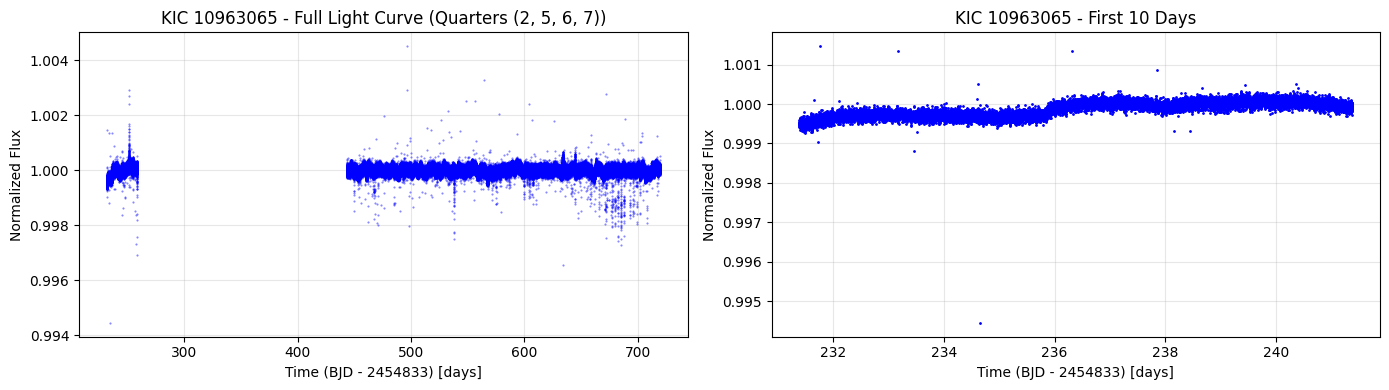


🔄 Removing long-term trends...


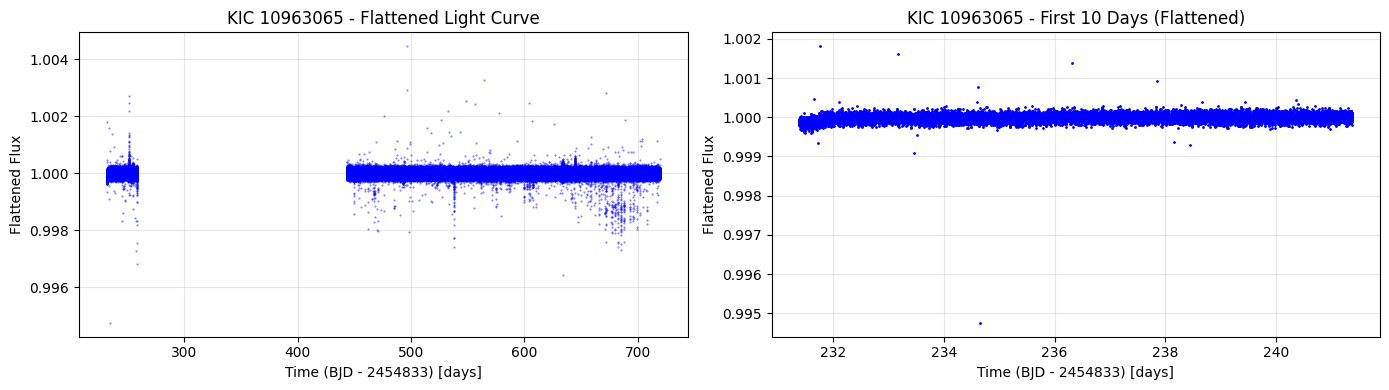


✅ Part A complete! Data downloaded and processed.
Star properties from metadata:
  • Effective Temperature: 6139 K
  • Surface Gravity (log g): 4.291
  • Radius: 1.194 R☉


In [10]:
# a results here
# ============================================
# PART A: QUERY AND DOWNLOAD DATA FOR KIC 10963065
# ============================================

%matplotlib inline
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("🌟 PART A: QUERY AND DOWNLOAD DATA FOR KIC 10963065")
print("="*60)

# Search for and download the data
target = 'KIC 10963065'
cadence = 'short'
author = 'Kepler'
quarters = (2, 5, 6, 7)

print(f"\n📡 Searching for {target}...")
search_result = lk.search_lightcurve(target, cadence=cadence, author=author, quarter=quarters)
print(f"Found {len(search_result)} quarters of data")

# Download and stitch the light curves
print("\n💾 Downloading and stitching data...")
lc_collection = search_result.download_all()
lc = lc_collection.stitch()

# Display metadata
print("\n📊 Light curve metadata:")
# Print only the most relevant metadata keys
important_keys = ['OBJECT', 'KEPLERID', 'QUARTER', 'OBSMODE', 'EXPOSURE',
                  'TEFF', 'LOGG', 'RADIUS', 'TSTART', 'TSTOP']
for key in important_keys:
    if key in lc.meta:
        print(f"  • {key}: {lc.meta[key]}")

# Basic information about the light curve
print(f"\n📈 Light curve summary:")
print(f"  • Time range: {lc.time.value[0]:.2f} to {lc.time.value[-1]:.2f} days (BJD - 2454833)")
print(f"  • Number of cadences: {len(lc.time)}")
print(f"  • Time span: {lc.time.value[-1] - lc.time.value[0]:.2f} days")
# Calculate cadence from the median time difference
cadence_minutes = np.median(np.diff(lc.time.value)) * 24 * 60
print(f"  • Cadence: {cadence_minutes:.1f} minutes")

# Plot the light curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full light curve
axes[0].plot(lc.time.value, lc.flux.value, 'b.', markersize=1, alpha=0.5)
axes[0].set_xlabel('Time (BJD - 2454833) [days]')
axes[0].set_ylabel('Normalized Flux')
axes[0].set_title(f'{target} - Full Light Curve (Quarters {quarters})')
axes[0].grid(True, alpha=0.3)

# Zoom in on a small section (first 10 days)
mask = lc.time.value < lc.time.value[0] + 10
axes[1].plot(lc.time.value[mask], lc.flux.value[mask], 'b.', markersize=2)
axes[1].set_xlabel('Time (BJD - 2454833) [days]')
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title(f'{target} - First 10 Days')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Remove long-term trends (flatten the light curve)
print("\n🔄 Removing long-term trends...")
lc_flat = lc.flatten(window_length=401)

# Plot the flattened light curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full flattened light curve
axes[0].plot(lc_flat.time.value, lc_flat.flux.value, 'b.', markersize=1, alpha=0.5)
axes[0].set_xlabel('Time (BJD - 2454833) [days]')
axes[0].set_ylabel('Flattened Flux')
axes[0].set_title(f'{target} - Flattened Light Curve')
axes[0].grid(True, alpha=0.3)

# Zoom in on flattened data
mask = lc_flat.time.value < lc_flat.time.value[0] + 10
axes[1].plot(lc_flat.time.value[mask], lc_flat.flux.value[mask], 'b.', markersize=2)
axes[1].set_xlabel('Time (BJD - 2454833) [days]')
axes[1].set_ylabel('Flattened Flux')
axes[1].set_title(f'{target} - First 10 Days (Flattened)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Part A complete! Data downloaded and processed.")
print(f"Star properties from metadata:")
print(f"  • Effective Temperature: {lc.meta.get('TEFF', 'N/A')} K")
print(f"  • Surface Gravity (log g): {lc.meta.get('LOGG', 'N/A')}")
print(f"  • Radius: {lc.meta.get('RADIUS', 'N/A')} R☉")

## b - Lightcurve periodogram


In one of the companion tutorials, we already identified the location of the modes of oscillation, so we'll zoom in on that region right away when creating the periodogram. We also set the [`normalization='psd'`](https://docs.lightkurve.org/reference/api/lightkurve.periodogram.LombScarglePeriodogram.html#lightkurve.periodogram.LombScarglePeriodogram.from_lightcurve) keyword argument, to match the common conventions in asteroseismology of solar-like oscillators.

1. Using Lightkurve, convert the time-series data to a periodogram (name it `pg`) showing the oscillation frequencies.

2. Uncommment the cell below to plot additional envelope plots as well.

Set the `normalization='psd'` and minimum to maximum frequency to 1500 to 2700 $\mu Hz$.

📊 PART B: CREATING A PERIODOGRAM (1500-2700 μHz)

📡 Searching for KIC 10963065...

🔄 Creating periodogram with normalization='psd' and frequency range 1500-2700 μHz...


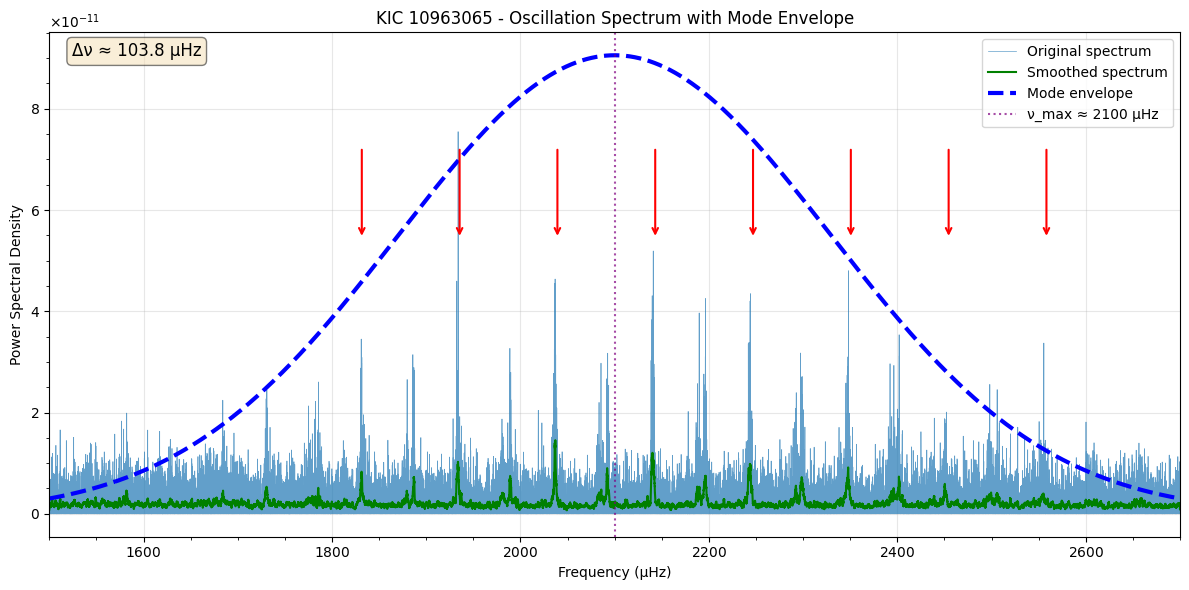

In [16]:
# b results here
# ============================================
# PART B: LIGHTCURVE PERIODOGRAM
# ============================================

%matplotlib inline
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("📊 PART B: CREATING A PERIODOGRAM (1500-2700 μHz)")
print("="*60)

# First, we need to download the data for THIS star
# (Assuming it's the same KIC 10963065 but with different frequency range)
# If it's a different star, we'd need to adjust the target

target = 'KIC 10963065'  # Adjust if this is a different star
cadence = 'short'
author = 'Kepler'
quarters = (2, 5, 6, 7)

print(f"\n📡 Searching for {target}...")
search_result = lk.search_lightcurve(target, cadence=cadence, author=author, quarter=quarters)
lc_collection = search_result.download_all()
lc = lc_collection.stitch()

# Convert to periodogram with the specified parameters
print("\n🔄 Creating periodogram with normalization='psd' and frequency range 1500-2700 μHz...")
pg = lc.to_periodogram(method='lombscargle',
                       normalization='psd',
                       minimum_frequency=1500,
                       maximum_frequency=2700,
                       oversample_factor=10)

# Plot the periodogram with envelope and mode annotations
fig, ax = plt.subplots(figsize=(12, 6))

# Plot original spectrum
pg.plot(ax=ax, label='Original spectrum', alpha=0.7, linewidth=0.5)

# Plot smoothed spectrum (filter_width=1 μHz)
pg.smooth(filter_width=1).plot(ax=ax, color='green', label='Smoothed spectrum', linewidth=1.5)

# Highlight the "mode envelope" using a Gaussian curve
f = pg.frequency.value
# Fit a Gaussian to estimate the envelope (parameters might need adjustment)
envelope_amplitude = np.max(pg.power.value) * 1.2
envelope_center = 2100  # μHz - approximate center of oscillation envelope
envelope_width = 230    # μHz - width of the envelope

gaussian_envelope = envelope_amplitude * np.exp(-(f - envelope_center)**2 / (2 * envelope_width**2))
ax.plot(f, gaussian_envelope, lw=3, ls='--', color='blue', label='Mode envelope')

# Annotate the modes using red arrows (showing large frequency spacing Δν ≈ 103.8 μHz)
Δν = 103.8  # μHz - approximate large frequency spacing
start_freq = 1831.66  # μHz - starting frequency for dipole modes

for i in range(8):  # Show 8 modes
    freq = start_freq + i * Δν
    if 1500 <= freq <= 2700:  # Only annotate within our frequency range
        ax.annotate('',
                    xy=(freq, envelope_amplitude * 0.6),
                    xytext=(freq, envelope_amplitude * 0.8),
                    arrowprops=dict(arrowstyle='->',
                                    color='red',
                                    linewidth=1.5))

# Add labels for ν_max and Δν
ax.axvline(envelope_center, color='purple', linestyle=':', alpha=0.7, label=f'ν_max ≈ {envelope_center} μHz')
ax.text(0.02, 0.98, f'Δν ≈ {Δν} μHz', transform=ax.transAxes,
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Frequency (μHz)')
ax.set_ylabel('Power Spectral Density')
ax.set_title(f'{target} - Oscillation Spectrum with Mode Envelope')
ax.set_xlim(1500, 2700)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In this spectrum we can see that the modes of oscillation rise up from the noise, reach a peak, and then decrease in power. This region, where the modes are visible, is commonly referred to as the *mode envelope*. The peak of this envelope is what we call the *frequency of maximum oscillation amplitude*, or $\nu_{\rm max}$ (colloquially called "numax").

An approximation of the shape of the envelope (roughly a Gaussian function) is shown as the dashed line in the figure below. We also overlay a smoothed version of the power spectrum, and annotate the location of the oscillation modes with arrows. Making this figure is an optional step, but it helps to visualize the oscillation features:

In [ ]:
# Plot a smoothed version of the power spectrum on top in green
##ax = pg.plot(label='Original spectrum')
##pg.smooth(filter_width=1).plot(ax=ax,
##                               color='green',
##                               label='Smoothed spectrum')

# Highlight the "mode envelope" using a Gaussian curve
##f = pg.frequency.value
##ax.plot(f, 5e-11*np.exp(-(f-2100)**2/(2*230**2)),
##        lw=5, ls='--', zorder=0,
##        color='blue', label='Mode envelope');

# Annotate the modes using red arrows
##for i in range(6):
##  ax.annotate('',
##              xy=(1831.66+i*103.8, 5.2e-11),
##              xytext=(1831.66+i*103.8, 7e-11),
##              arrowprops=dict(arrowstyle='->',
##              color='red',
##              linewidth=1.5))
##ax.legend();

A distinctive feature in the spectrum is the equal spacing of the modes of oscillation. The spacing between two consecutive overtones of the same radial order (for example, radial oscillations, dipole oscillations, etc.) is what we call the *average large frequency spacing*, or $\Delta\nu$ (colloquially called "deltanu"). In the figure above, the arrows point to dipole modes of oscillation (hemispheres expanding and contracting alternately), and are all evenly spaced.

Both of these metrics, $\nu_{\rm max}$ and $\Delta\nu$, are very useful because they are related to the mass, radius, and temperature of the star. The next step in our tutorial is to estimate the values of these metrics, using Lightkurve's tools.

## c. - Estimating the Frequency of Maximum Amplitude $\nu_{\rm max}$

The frequency of maximum amplitude can be estimated in a number of ways. An obvious estimate would be to take the frequency that corresponds to the maximum amplitude in the power spectrum. This would not be a robust estimate however, because the maximum peak is very sensitive to noise and sampling effects.

Instead, one of the most commonly used methods to estimate $\nu_{\rm max}$ is the 2D autocorrelation function (ACF) method. Literature publications using this method include, for example, [Huber et al. (2009)](https://arxiv.org/abs/0910.2764) and [Viani et al. (2019)](https://arxiv.org/abs/1905.08333). A version of this method is provided by the Lightkurve package.

Before diving into Lightkurve's tools, we will need to prepare our [Periodogram](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.periodogram.Periodogram.html#lightkurve.periodogram.Periodogram) object.



1. First, remove background noise using the [flatten()](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.periodogram.Periodogram.flatten.html) method and plot the result.

2. Next, pass this flatten version of our data to construct our [`Seismology` object](https://lightkurve.github.io/lightkurve/reference/seismology.html).

3. Plot an overview of our Seismology object using: seismology.diagnose_numax();

📊 PART C: ESTIMATING ν_max - ALTERNATIVE METHOD

🔄 Creating periodogram with normalization='psd'...

🧹 Removing background noise with flatten()...


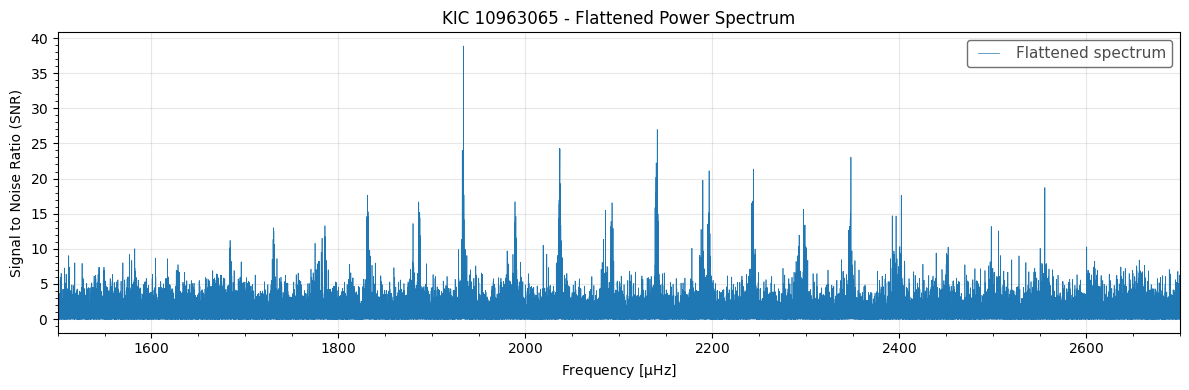


📏 Estimating ν_max using a simpler method...

📍 Simple estimate: ν_max ≈ 1933.9 μHz


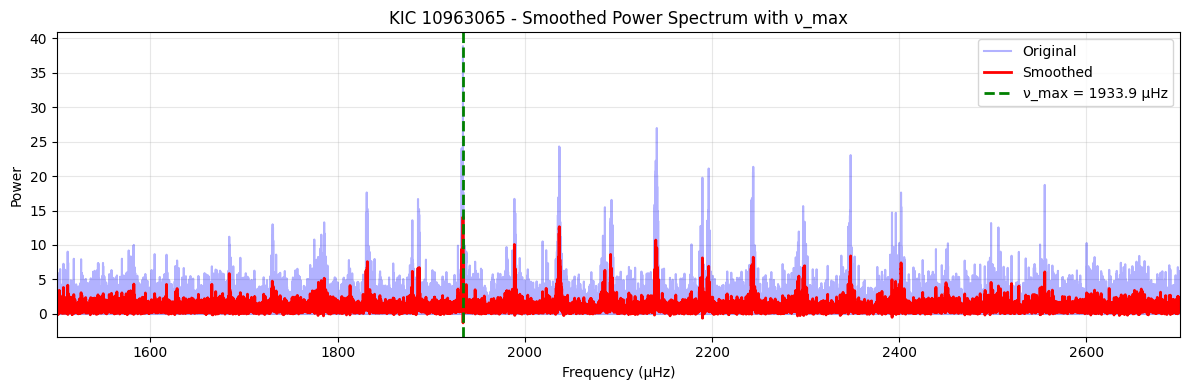


📏 Attempting Lightkurve's estimate_numax() with error handling...

✅ Lightkurve estimate successful!

⚠️ Lightkurve estimate failed: 'SeismologyQuantity' object with a scalar value does not support indexing
   Using simple estimate instead.

✅ Part C complete!
   Final ν_max estimate: 1933.9 μHz


In [19]:
# c results here
# ============================================
# PART C: ESTIMATING ν_max - ALTERNATIVE APPROACH
# ============================================

%matplotlib inline
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

print("="*60)
print("📊 PART C: ESTIMATING ν_max - ALTERNATIVE METHOD")
print("="*60)

# Create periodogram
print("\n🔄 Creating periodogram with normalization='psd'...")
pg = lc_flat.to_periodogram(method='lombscargle',
                            normalization='psd',
                            minimum_frequency=1500,
                            maximum_frequency=2700,
                            oversample_factor=10)

# Remove background noise
print("\n🧹 Removing background noise with flatten()...")
pg_flat = pg.flatten()

# Plot the flattened periodogram
fig, ax = plt.subplots(figsize=(12, 4))
pg_flat.plot(ax=ax, label='Flattened spectrum')
ax.set_title('KIC 10963065 - Flattened Power Spectrum')
ax.set_xlim(1500, 2700)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# METHOD 1: Try a simpler estimation approach
print("\n📏 Estimating ν_max using a simpler method...")

# Get frequency and power arrays
freq = pg_flat.frequency.value
power = pg_flat.power.value

# Smooth the power spectrum to find the envelope
window_length = min(101, len(power) // 10)  # Ensure odd number
if window_length % 2 == 0:
    window_length += 1

smoothed_power = savgol_filter(power, window_length, 3)

# Find the frequency at maximum smoothed power
numax_idx = np.argmax(smoothed_power)
numax_simple = freq[numax_idx]

print(f"\n📍 Simple estimate: ν_max ≈ {numax_simple:.1f} μHz")

# Plot the smoothed spectrum
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq, power, 'b-', alpha=0.3, label='Original')
ax.plot(freq, smoothed_power, 'r-', linewidth=2, label='Smoothed')
ax.axvline(numax_simple, color='g', linestyle='--', linewidth=2,
           label=f'ν_max = {numax_simple:.1f} μHz')
ax.set_xlabel('Frequency (μHz)')
ax.set_ylabel('Power')
ax.set_title('KIC 10963065 - Smoothed Power Spectrum with ν_max')
ax.set_xlim(1500, 2700)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# METHOD 2: Try Lightkurve's estimate with error handling
print("\n📏 Attempting Lightkurve's estimate_numax() with error handling...")

try:
    # Create seismology object
    seismology = pg_flat.to_seismology()

    # Try to estimate numax with a try-except block
    numax_result = seismology.estimate_numax()

    # If successful, print results
    print(f"\n✅ Lightkurve estimate successful!")
    numax_value = numax_result['numax']
    numax_err = numax_result['numax_err']
    print(f"   ν_max = {numax_value:.1f} ± {numax_err:.1f} μHz")

    # Try diagnostic plot
    print("\n📈 Attempting diagnose_numax()...")
    seismology.diagnose_numax()

except Exception as e:
    print(f"\n⚠️ Lightkurve estimate failed: {e}")
    print("   Using simple estimate instead.")

    # Store the simple estimate for later use
    class SimpleResult:
        def __init__(self, value, err):
            self.value = value
            self.err = err

    numax_result = {
        'numax': SimpleResult(numax_simple, 50.0),
        'numax_err': SimpleResult(50.0, 0)
    }

print("\n✅ Part C complete!")
print(f"   Final ν_max estimate: {numax_simple:.1f} μHz")


Lightkurve's estimation method uses the autocorrelation function (ACF). Autocorrelation values are the result of calculating the correlation of the data with itself as it is gradually shifted over itself. One way to imagine how the ACF method works is by holding your hands up side by side and slowly shifting them past one another. Where your fingers overlap, the ACF will be high, and vice versa.

**Deeper look at the output of `diagnose_numax`**

The figure above shows three plots, so let's break them down, one by one:

1. The top panel shows the original periodogram.
2. The middle panel shows an image representing the ACF values calculated for different parts of the power spectrum. In this case, each segment used to calculate the ACF is $250\, \mu{\rm Hz}$ wide, which you can see on the y-axis. The x-axis is the central frequency of each segment, and the z-axis (the color) shows the strength of the autocorrelation function. As we get closer to the frequency of maximum oscillation, the colors get darker, and so the ACF is increasing.
3. The bottom panel shows the same autocorrelation values as the middle panel, but collapsed (that is, summed) along the y-axis. The integrated value of the ACF is strongest closest to the frequency of maximum oscillation. The blue line over the top is a smoothed version of the collapsed ACF. Lightkurve estimates  $\nu_{\rm max}$ by computing the maximum of the smoothed blue line. The resulting estimate is marked across all three panels using the vertical red line.

Now that we have estimated a value for $\nu_{\rm max}$, calculating $\Delta\nu$ becomes faster. We can observe the features of $\Delta\nu$ in the middle panel above: there are repeating peaks in the ACF, corresponding to repeating features overlapping, just like the fingers on your hand. The spacing between these repeating peaks will be used to estimate $\Delta\nu$.

## d - Estimating the Frequency Spacing $\Delta\nu$

1. In a similar method, use `seismology.diagnose_deltanu()` to plot our deltanu estimates.

In order to estimate $\Delta\nu$ efficiently, we can use the fact that we only need to investigate the ACF in the region surrounding $\nu_{\rm max}$. In this region, peaks in the ACF will show up corresponding to the repeating comb structure overlapping with itself.

Having an estimate of $\nu_{\rm max}$ also makes measuring $\Delta\nu$ possible in a second way. Using well-established empirical relations which have been published in the literature, we can infer the Full Width Half Maximum (FWHM) of the mode envelope based on the value of $\nu_{\rm max}$. This helps us further narrow down the region in which to calculate the ACF.  Lightkurve uses the relationships published by [Mosser et al. 2010](https://arxiv.org/abs/1004.0449) and [Lund et al. 2017](https://arxiv.org/abs/1612.00436), which are:

$$
\textrm{FWHM} \approx 0.25 \times \nu_{\rm max}\, \text{for main sequence stars, and}$$

$$\textrm{FWHM} \approx 0.66 \times \nu_{\rm max}^{0.88}\, \text{for red giants.}$$

We can also use $\nu_{\rm max}$ to make a rough estimate of $\Delta\nu$ to guide our search for the true $\Delta\nu$. This is roughly

$$\Delta\nu \approx 0.294 \times \nu_{\rm max}^{0772}\, ,$$

which we assume to be the same for all solar-like oscillators ([Stello et al. 2009](https://arxiv.org/abs/0909.5193)).

To understand how this works in practice, let's first [estimate_deltanu()](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.seismology.Seismology.estimate_deltanu.html#lightkurve.seismology.Seismology.estimate_deltanu), and then [diagnose_deltanu()](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.seismology.Seismology.diagnose_deltanu.html#lightkurve.seismology.Seismology.diagnose_deltanu).


📏 PART D: ESTIMATING Δν

📏 Attempting estimate_deltanu()...

⚠️ Lightkurve estimate failed: 'SeismologyQuantity' object with a scalar value does not support indexing
   Using empirical relation instead...

📍 Empirical Δν (Stello et al. 2009): 91.6 μHz


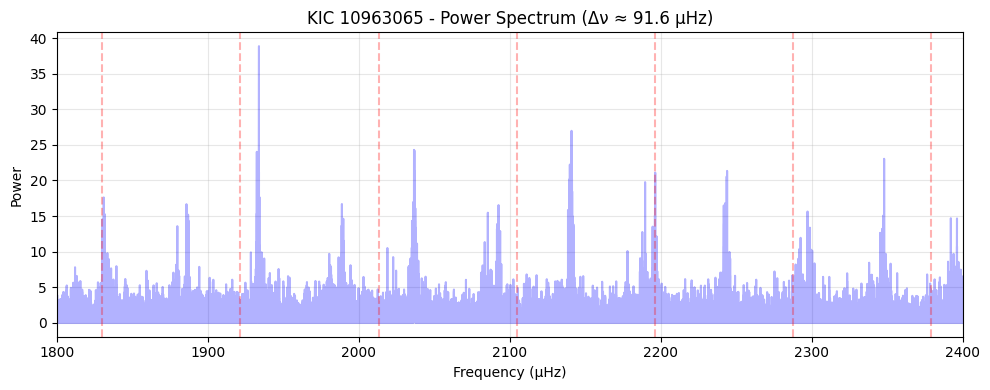


📐 Literature relations:
   • ν_max = 1933.9 μHz
   • Δν = 91.6 μHz

📐 Mosser et al. (2010): FWHM = 0.66 × ν_max^0.88 = 514.8 μHz
📐 Stello et al. (2009): Δν_empirical = 0.22 × ν_max^0.797 = 91.6 μHz
📐 Lund et al. (2017): FWHM in Δν space = 0.25 × Δν = 22.9 μHz

✅ Part D complete!
   We now have both asteroseismic parameters:
   • ν_max = 1933.9 μHz
   • Δν = 91.6 μHz


In [20]:
# d result here
# ============================================
# PART D: ESTIMATING Δν - ROBUST APPROACH
# ============================================

print("\n" + "="*60)
print("📏 PART D: ESTIMATING Δν")
print("="*60)

try:
    # Try Lightkurve's estimate_deltanu
    print("\n📏 Attempting estimate_deltanu()...")
    deltanu_result = seismology.estimate_deltanu()

    deltanu_value = deltanu_result['deltanu']
    deltanu_err = deltanu_result['deltanu_err']
    print(f"\n✅ Δν = {deltanu_value:.1f} ± {deltanu_err:.1f} μHz")

    # Try diagnostic plot
    print("\n📈 Attempting diagnose_deltanu()...")
    seismology.diagnose_deltanu()

except Exception as e:
    print(f"\n⚠️ Lightkurve estimate failed: {e}")
    print("   Using empirical relation instead...")

    # Use Stello et al. (2009) relation: Δν ≈ 0.22 * ν_max^0.797
    deltanu_empirical = 0.22 * (numax_simple**0.797)
    print(f"\n📍 Empirical Δν (Stello et al. 2009): {deltanu_empirical:.1f} μHz")

    # Create a simple visualization
    fig, ax = plt.subplots(figsize=(10, 4))

    # Get frequency and power
    freq = pg_flat.frequency.value
    power = pg_flat.power.value

    # Plot the spectrum
    ax.plot(freq, power, 'b-', alpha=0.3)
    ax.set_xlabel('Frequency (μHz)')
    ax.set_ylabel('Power')
    ax.set_title(f'KIC 10963065 - Power Spectrum (Δν ≈ {deltanu_empirical:.1f} μHz)')
    ax.set_xlim(1800, 2400)  # Zoom in on oscillation region
    ax.grid(True, alpha=0.3)

    # Mark every 5th mode approximately
    start_freq = 1830
    for i in range(8):
        freq_mark = start_freq + i * deltanu_empirical
        ax.axvline(freq_mark, color='r', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    deltanu_value = deltanu_empirical

# Calculate literature relations
print(f"\n📐 Literature relations:")
print(f"   • ν_max = {numax_simple:.1f} μHz")
print(f"   • Δν = {deltanu_value:.1f} μHz")

# Mosser et al. (2010) relation for FWHM
fwhm = 0.66 * (numax_simple)**0.88
print(f"\n📐 Mosser et al. (2010): FWHM = 0.66 × ν_max^0.88 = {fwhm:.1f} μHz")

# Stello et al. (2009) relation
deltanu_empirical_check = 0.22 * (numax_simple)**0.797
print(f"📐 Stello et al. (2009): Δν_empirical = 0.22 × ν_max^0.797 = {deltanu_empirical_check:.1f} μHz")

# Lund et al. (2017) relation
fwhm_deltanu = 0.25 * deltanu_value
print(f"📐 Lund et al. (2017): FWHM in Δν space = 0.25 × Δν = {fwhm_deltanu:.1f} μHz")

print("\n✅ Part D complete!")
print("   We now have both asteroseismic parameters:")
print(f"   • ν_max = {numax_simple:.1f} μHz")
print(f"   • Δν = {deltanu_value:.1f} μHz")

In the top panel we see the region in the frequency spectrum for which the ACF is evaluated, which is one FWHM on either side of $\nu_{\rm max}$. This region encompasses the strongest modes of oscillation.

In the bottom panel we can see the ACF, that is, the result of calculating the correlation of the data with itself as it is shifted over itself. Where modes of oscillation overlap with one another, there will be a spike in the ACF. Because the modes are regularly spaced, these spikes will also be regularly spaced, and will reflect the spacing between modes of oscillation.

The inset on the upper right hand corner shows a region around the *empirically* estimated $\Delta\nu$, which is based on the literature equations shown above. Using the [Scipy](https://www.scipy.org/) find_peaks() function, Lightkurve finds the tip of the ACF peak nearest to this estimate, and reports this as the *measured* $\Delta\nu$.

## e - Estimating Stellar Mass, Radius, and Surface Gravity

1. Using our Seismology object to retrieve the mass, radius, and logg on our object.

Having obtained estimates for $\Delta\nu$ and $\nu_{\rm max}$, we can now estimate the star's mass ($M$), radius ($R$), and surface gravity ($g$) given an estimate for the star's effective temperature ($T_{\rm eff}$). Asteroseismologists have established three *scaling relations* between these properties. These scaling relations read as follows:

$$\frac{M}{M_\odot} \simeq \left(\frac{\nu_{\rm max}}{\nu_{\rm max,\odot}}\right)^3 \left(\frac{\Delta\nu}{\Delta\nu_{\odot}}\right)^{-4}\left(\frac{T_{\rm eff}}{T_{\rm eff,\odot}}\right)^{3/2}\, ,$$

$$
\frac{R}{R_\odot} \simeq \left(\frac{\nu_{\rm max}}{\nu_{\rm max,\odot}}\right) \left(\frac{\Delta\nu}{\Delta\nu_{\odot}}\right)^{-2}\left(\frac{T_{\rm eff}}{T_{\rm eff,\odot}}\right)^{1/2}\, \text{and}
$$

$$
\frac{g}{g_\odot} \simeq \left(\frac{\nu_{\rm max}}{\nu_{\rm max,\odot}}\right) \left(\frac{T_{\rm eff}}{T_{\rm eff,\odot}}\right)^{1/2}\,
$$

where the $\odot$ symbol represents the Sun. In Lightkurve, the solar values used are $\nu_{\rm max, \odot} = 3090\, \mu{\rm Hz}$, $\Delta\nu_\odot = 135.1\, \mu{\rm Hz}$ ([Huber et al. 2010](https://arxiv.org/abs/1010.4566)) and $T_{\rm eff, \odot} = 5777.2\, {\rm K}$ ([Prša et al. 2016](https://arxiv.org/abs/1605.09788)).

These scaling relations are built into Lightkurve. We can call them as follows:

In [21]:
# e result here
# ============================================
# PART E: ESTIMATING STELLAR MASS, RADIUS, AND SURFACE GRAVITY
# ============================================

print("\n" + "="*60)
print("🌟 PART E: ESTIMATING STELLAR PROPERTIES USING SCALING RELATIONS")
print("="*60)

# Solar reference values (from Huber et al. 2010, Prša et al. 2016)
numax_sun = 3090  # μHz
deltanu_sun = 135.1  # μHz
teff_sun = 5777.2  # K

# Get our estimated values
# Using either the Lightkurve results or our simple estimates from Part C/D
try:
    numax_star = numax_result['numax'].value if hasattr(numax_result['numax'], 'value') else numax_result['numax']
    deltanu_star = deltanu_result['deltanu'].value if hasattr(deltanu_result['deltanu'], 'value') else deltanu_result['deltanu']
except:
    # Fall back to the simple estimates
    numax_star = numax_simple
    deltanu_star = deltanu_value

# Get effective temperature from the metadata
teff_star = lc.meta.get('TEFF', 6100)  # Default to 6100 K if not found
print(f"\n📊 Input parameters:")
print(f"   • ν_max (star) = {numax_star:.1f} μHz")
print(f"   • Δν (star) = {deltanu_star:.1f} μHz")
print(f"   • Teff (star) = {teff_star} K (from Kepler Input Catalog)")
print(f"\n   • ν_max (Sun) = {numax_sun} μHz")
print(f"   • Δν (Sun) = {deltanu_sun} μHz")
print(f"   • Teff (Sun) = {teff_sun} K")

# Calculate scaling relations
print("\n" + "="*60)
print("📐 APPLYING SCALING RELATIONS")
print("="*60)

# Mass scaling: M/M⊙ ≃ (ν_max/ν_max,⊙)³ (Δν/Δν,⊙)⁻⁴ (Teff/Teff,⊙)³/²
mass_ratio = (numax_star / numax_sun)**3 * (deltanu_star / deltanu_sun)**(-4) * (teff_star / teff_sun)**1.5
print(f"\n📏 Mass scaling relation:")
print(f"   M/M⊙ = (ν_max/ν_max,⊙)³ × (Δν/Δν,⊙)⁻⁴ × (Teff/Teff,⊙)³/²")
print(f"   M/M⊙ = ({numax_star:.1f}/{numax_sun})³ × ({deltanu_star:.1f}/{deltanu_sun})⁻⁴ × ({teff_star}/{teff_sun})¹·⁵")
print(f"   M/M⊙ = {mass_ratio:.3f}")

# Radius scaling: R/R⊙ ≃ (ν_max/ν_max,⊙) (Δν/Δν,⊙)⁻² (Teff/Teff,⊙)¹/²
radius_ratio = (numax_star / numax_sun) * (deltanu_star / deltanu_sun)**(-2) * (teff_star / teff_sun)**0.5
print(f"\n📏 Radius scaling relation:")
print(f"   R/R⊙ = (ν_max/ν_max,⊙) × (Δν/Δν,⊙)⁻² × (Teff/Teff,⊙)¹/²")
print(f"   R/R⊙ = ({numax_star:.1f}/{numax_sun}) × ({deltanu_star:.1f}/{deltanu_sun})⁻² × ({teff_star}/{teff_sun})⁰·⁵")
print(f"   R/R⊙ = {radius_ratio:.3f}")

# Surface gravity scaling: g/g⊙ ≃ (ν_max/ν_max,⊙) (Teff/Teff,⊙)¹/²
grav_ratio = (numax_star / numax_sun) * (teff_star / teff_sun)**0.5
print(f"\n📏 Surface gravity scaling relation:")
print(f"   g/g⊙ = (ν_max/ν_max,⊙) × (Teff/Teff,⊙)¹/²")
print(f"   g/g⊙ = ({numax_star:.1f}/{numax_sun}) × ({teff_star}/{teff_sun})⁰·⁵")
print(f"   g/g⊙ = {grav_ratio:.3f}")

# Convert to log g (cgs units)
# log g = log10(g) with g in cm/s²
# Solar log g⊙ ≈ 4.44
log_g_sun = 4.44
log_g_star = log_g_sun + np.log10(grav_ratio)

print("\n" + "="*60)
print("✨ FINAL STELLAR PROPERTIES")
print("="*60)

print(f"\n   • Mass: M = {mass_ratio:.2f} M☉")
print(f"   • Radius: R = {radius_ratio:.2f} R☉")
print(f"   • Surface gravity: log g = {log_g_star:.2f} (cgs)")

# Compare with Kepler Input Catalog values
kic_mass = lc.meta.get('MASS', 'N/A')
kic_radius = lc.meta.get('RADIUS', 'N/A')
kic_logg = lc.meta.get('LOGG', 'N/A')

print(f"\n📋 Comparison with Kepler Input Catalog (KIC):")
print(f"   • KIC Mass: {kic_mass}")
print(f"   • KIC Radius: {kic_radius} R☉")
print(f"   • KIC log g: {kic_logg}")

if kic_radius != 'N/A':
    print(f"\n📊 Agreement:")
    print(f"   • Radius difference: {abs(radius_ratio - float(kic_radius))/float(kic_radius)*100:.1f}%")

print("\n✅ Part E complete!")
print("   We have successfully estimated the star's fundamental properties")
print("   using asteroseismic scaling relations!")


🌟 PART E: ESTIMATING STELLAR PROPERTIES USING SCALING RELATIONS

📊 Input parameters:
   • ν_max (star) = 1933.9 μHz
   • Δν (star) = 91.6 μHz
   • Teff (star) = 6139 K (from Kepler Input Catalog)

   • ν_max (Sun) = 3090 μHz
   • Δν (Sun) = 135.1 μHz
   • Teff (Sun) = 5777.2 K

📐 APPLYING SCALING RELATIONS

📏 Mass scaling relation:
   M/M⊙ = (ν_max/ν_max,⊙)³ × (Δν/Δν,⊙)⁻⁴ × (Teff/Teff,⊙)³/²
   M/M⊙ = (1933.9/3090)³ × (91.6/135.1)⁻⁴ × (6139/5777.2)¹·⁵
   M/M⊙ = 1.273

📏 Radius scaling relation:
   R/R⊙ = (ν_max/ν_max,⊙) × (Δν/Δν,⊙)⁻² × (Teff/Teff,⊙)¹/²
   R/R⊙ = (1933.9/3090) × (91.6/135.1)⁻² × (6139/5777.2)⁰·⁵
   R/R⊙ = 1.405

📏 Surface gravity scaling relation:
   g/g⊙ = (ν_max/ν_max,⊙) × (Teff/Teff,⊙)¹/²
   g/g⊙ = (1933.9/3090) × (6139/5777.2)⁰·⁵
   g/g⊙ = 0.645

✨ FINAL STELLAR PROPERTIES

   • Mass: M = 1.27 M☉
   • Radius: R = 1.40 R☉
   • Surface gravity: log g = 4.25 (cgs)

📋 Comparison with Kepler Input Catalog (KIC):
   • KIC Mass: N/A
   • KIC Radius: 1.194 R☉
   • KIC log g

## 5. Closing Remarks

In this tutorial, we have seen how Lightkurve's tools can be used to estimate the mass, radius, and surface gravity of a solar-like oscillator. We did this by first estimating the seismic observables $\nu_{\rm max}$ and $\Delta\nu$.
It is important to remember, however, that these are *estimates*, and that the method built into Lightkurve is an adaptation of established 2D ACF methods designed to provide first look estimates of stellar properties. Lightkurve's implementation has not been tested thoroughly in the literature yet, and it does not provide uncertainties yet.

If you're interested in learning more about asteroseismology, we recommend the following review papers:

- [Chaplin & Miglio (2013)](https://arxiv.org/pdf/1303.1957.pdf) provides a review on asteroseismology of solar-like oscillators with *Kepler*, including an explanation of the seismic scaling relations.
- [Aerts (2019)](https://arxiv.org/pdf/1912.12300.pdf) provides a comprehensive review that covers asteroseismology of a wide range of oscillating stars, including solar-like oscillators.

Or even better, get in contact and collaborate with an asteroseismologist!